# **Skills in CrewAI**

### Skills are self-contained directories that provide agents with domain-specific instructions, guidelines, and reference material.

### Each skill is defined by a SKILL.md file with YAML frontmatter and a markdown body.

### When activated, a skill’s instructions are injected directly into the agent’s task prompt — giving the agent expertise without requiring any code changes


### **Skills are NOT tools.** This is the most common point of confusion.

### Skills inject instructions and context into the agent’s prompt. They tell the agent how to think about a problem.

### Tools give the agent callable functions to take action (search, read files, call APIs).

### You often need both: skills for expertise, tools for action. They are configured independently and complement each other.


### A **Skill** tells an agent **how to perform a type of work**.

### A **Tool** gives the agent the **ability to perform an action**.


## **Skill**: "Follow these steps when conducting financial analysis."

## **Tool**: "Call Yahoo Finance to retrieve financial data."

# Install Libraries

In [ ]:
!pip install -q crewai crewai_tools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.5/195.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.2/833.2 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48

# Version Check

After successful installation....

In [ ]:
import crewai
import crewai_tools
print(crewai.__version__)
print(crewai_tools.__version__)

# Set API Keys for LLMs & Tools

In [ ]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY_NEW')
# os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

# Create a Folder Structure to organize the Skills

In [ ]:
!mkdir market_research_crew
!mkdir -p market_research_crew/skills/market-research-methodology
!mkdir -p market_research_crew/skills/investment-analysis

# Write the Skill.md files for the market research skill and investment analysis skill.

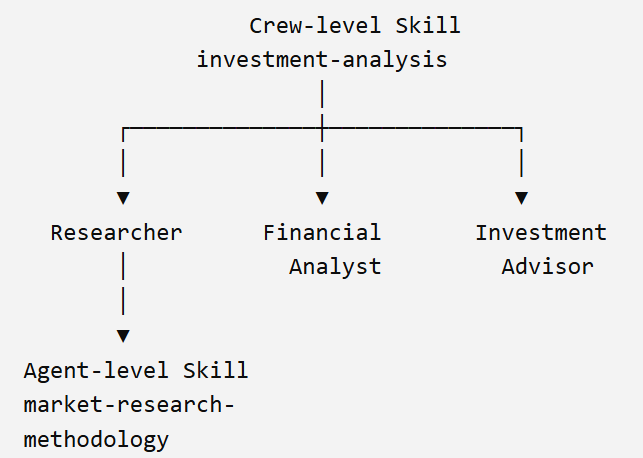

# Define an Agent-level Skill

In [ ]:
%%writefile market_research_crew/skills/market-research-methodology/Skill.md
---
name: market-research-methodology
description: Methodology for conducting structured company and market research.
metadata:
  author: university
  version: "1.0"
---

# Market Research Methodology

You are a professional market research analyst.

When researching a company or market, follow this methodology.

## 1. Company Overview

Identify:

- What the company does
- Major products or services
- Primary markets
- Major revenue sources
- Competitive positioning

## 2. Market Analysis

Analyze:

- Target market
- Market growth
- Major industry trends
- Growth opportunities
- Potential disruptions

## 3. Competitive Analysis

Identify at least three major competitors.

For each competitor consider:

- Market position
- Product strengths
- Competitive advantage
- Potential threat to the target company

## 4. Evidence

Separate:

- Established facts
- Reasonable interpretations
- Speculation

Do not present speculation as fact.

## 5. Research Output

Produce the research using this structure:

1. Company Overview
2. Market Overview
3. Competitive Landscape
4. Growth Opportunities
5. Major Risks
6. Key Findings

Keep findings concise and evidence-oriented.

# Define a Crew-level Skill

In [ ]:
%%writefile market_research_crew/skills/investment-analysis/Skill.md
---
name: investment-analysis
description: Common methodology for producing disciplined investment analysis and recommendations.
metadata:
  author: university
  version: "1.0"
---

# Investment Analysis Methodology

All agents participating in this crew must follow these principles.

## 1. Evidence-Based Analysis

Distinguish clearly between:

- Facts
- Analysis
- Assumptions
- Risks
- Recommendations

Never invent financial information.

## 2. Analyze Four Dimensions

Investment analysis should consider:

### Business

- Business model
- Products
- Competitive advantage
- Growth opportunities

### Financial

- Revenue growth
- Profitability
- Cash flow
- Valuation
- Financial risks

### Market

- Industry growth
- Competition
- Market trends
- External threats

### Risk

Consider:

- Business risks
- Competitive risks
- Market risks
- Regulatory risks
- Technology risks

## 3. Recommendation

The final recommendation must be one of:

- BUY
- HOLD
- AVOID

The recommendation must be supported by explicit evidence.

## 4. Confidence

Assign:

- HIGH
- MEDIUM
- LOW

confidence to the recommendation.

Explain the main factors affecting confidence.

## 5. Report Style

Use:

- Clear headings
- Concise paragraphs
- Tables where useful
- Explicit assumptions
- Evidence-based conclusions

Avoid exaggerated claims.

The final report should allow a reader to understand both the opportunity and the risks.

Writing market_research_crew/skills/investment-analysis/Skill.md


# Import necessary classes/methods from the package

In [ ]:
from crewai import Agent, Task, Crew, LLM, Process

# Define the LLM Object

In [ ]:
# Create an LLM with a temperature of 0 to ensure deterministic outputs from the LLM
# Set temperature to higher values for creative outputs from the LLM

# OPENAI LLMs
llm = LLM(
         # model="gpt-5.4-mini",
          model="gpt-5.4-nano",
          base_url="https://api.openai.com/v1",
          api_key = os.environ["OPENAI_API_KEY"],
          temperature=0.7)


# # GROQ hosted LLMs
# llm = LLM(
#      model="llama-3.3-70b-versatile",
#     #  model="openai/gpt-oss-120b",
#      base_url="https://api.groq.com/openai/v1",
#      api_key=os.environ["GROQ_API_KEY"],
#      temperature=0.7)


# Define Agents

In [ ]:
market_researcher = Agent(
    role="Market Research Analyst",

    goal=(
        "Conduct comprehensive research on the target company, "
        "its market, competitors, opportunities and threats."
    ),

    backstory=(
        "You are an experienced market intelligence analyst "
        "specializing in technology companies and competitive analysis."
    ),

    llm =llm,

    # AGENT-LEVEL SKILL
    skills=[
        "./market_research_crew/skills/market-research-methodology"
    ],

    verbose=True,
)


#---------------------------------------------------------------------
financial_analyst = Agent(
    role="Financial Analyst",

    goal=(
        "Analyze the company's financial performance, valuation, "
        "growth prospects and financial risks."
    ),

    backstory=(
        "You are a financial analyst experienced in evaluating "
        "technology companies and investment opportunities."
    ),
    llm =llm,

    # No agent-level skill here.
    # This agent receives the CREW-LEVEL skill.
    verbose=True,
)

#---------------------------------------------------------------------

investment_advisor = Agent(
    role="Investment Advisor",

    goal=(
        "Synthesize the market and financial analyses and produce "
        "a balanced investment recommendation."
    ),

    backstory=(
        "You are a senior investment advisor who converts "
        "research and financial analysis into actionable recommendations."
    ),
    llm =llm,

    # No agent-level skill.
    # This agent receives the CREW-LEVEL skill.
    verbose=True,
)


# Define Tasks

In [ ]:
research_task = Task(
    description="""
    Analyze the following company:

    {company}

    Conduct structured market research.

    Investigate:

    1. Company overview
    2. Main products and services
    3. Target markets
    4. Industry trends
    5. Major competitors
    6. Competitive advantages
    7. Growth opportunities
    8. Major threats and risks

    Follow the market research methodology provided by your skill.

    Clearly distinguish facts from interpretation.
    """,

    expected_output="""
    A structured market research report containing:

    - Company Overview
    - Market Overview
    - Competitive Landscape
    - Growth Opportunities
    - Major Risks
    - Key Findings
    """,

    agent=market_researcher,
)


#---------------------------------------------------------------------

financial_task = Task(
    description="""
    Analyze the financial and investment characteristics of:

    {company}

    Based on the available information and the market research
    provided by the previous analyst, evaluate:

    1. Revenue growth
    2. Profitability
    3. Cash-flow characteristics
    4. Business growth prospects
    5. Valuation considerations
    6. Financial risks
    7. Key assumptions

    Do not invent numerical financial data.

    Follow the investment-analysis methodology supplied to the crew.
    """,

    expected_output="""
    A structured financial analysis containing:

    - Financial Performance
    - Growth Prospects
    - Valuation Considerations
    - Financial Risks
    - Key Assumptions
    - Overall Financial Assessment
    """,

    agent=financial_analyst,

    context=[research_task],
)


#---------------------------------------------------------------------

recommendation_task = Task(
    description="""
    Produce a final investment assessment for:

    {company}

    Use the market research and financial analysis produced by
    the other agents.

    Your report must:

    1. Summarize the business opportunity
    2. Summarize the market position
    3. Summarize the financial outlook
    4. Identify the major risks
    5. Identify the strongest positive factors
    6. Identify the strongest negative factors
    7. Provide one recommendation:

       BUY
       HOLD
       AVOID

    8. Assign a confidence level:

       HIGH
       MEDIUM
       LOW

    9. Explain why the recommendation and confidence level
       were selected.

    Follow the investment-analysis skill strictly.
    """,

    expected_output="""
    A final investment recommendation report containing:

    Executive Summary

    Company Assessment

    Market Assessment

    Financial Assessment

    Key Opportunities

    Key Risks

    Recommendation:
    BUY / HOLD / AVOID

    Confidence:
    HIGH / MEDIUM / LOW

    Rationale
    """,

    agent=investment_advisor,

    context=[research_task, financial_task],
)


# Define the Crew (Orchestration Layer)

In [ ]:

crew = Crew(
    agents=[
        market_researcher,
        financial_analyst,
        investment_advisor,
    ],

    tasks=[
        research_task,
        financial_task,
        recommendation_task,
    ],

    process=Process.sequential,

    # CREW-LEVEL SKILL
    # All three agents receive this skill.
    skills=[
        "./market_research_crew/skills/investment-analysis"
    ],

    verbose=True,
)


# Run the Crew

In [ ]:
if __name__ == "__main__":

    company = input(
        "Enter the company to analyze "
        "(e.g., NVIDIA, Microsoft, Tesla): "
    )

    result = await crew.kickoff_async(
        inputs={
            "company": company
        }
    )

    print("\n")
    print("=" * 80)
    print("FINAL INVESTMENT REPORT")
    print("=" * 80)
    print(result)

Enter the company to analyze (e.g., NVIDIA, Microsoft, Tesla): NVIDIA


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: c3d54f9c-14a0-401d-b038-782b294e2a57                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Analyze the following company:                                                                             │
│                                                                                                                 │
│      NVIDIA                                                                                                     │
│                                                                                                                 │
│      Conduct structured market research.                                                                        │
│                                                                                                                 │
│      Investigate:                                                                                               │
│                                                                                                                 │
│      1. Company overview                                                                                        │
│      2. Main products and services                                                                              │
│      3. Target markets                                                                                          │
│      4. Industry trends                                                                                         │
│      5. Major competitors                                                                                       │
│      6. Competitive advantages                                                                                  │
│      7. Growth opportunities                                                                                    │
│      8. Major threats and risks                                                                                 │
│                                                                                                                 │
│      Follow the market research methodology provided by your skill.                                             │
│                                                                                                                 │
│      Clearly distinguish facts from interpretation.                                                             │
│                                                                                                                 │
│  ID: b3f48d7b-f4a8-473b-8010-74771a117ec5                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Market Research Analyst                                                                                 │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Analyze the following company:                                                                             │
│                                                                                                                 │
│      NVIDIA                                                                                                     │
│                                                                                                                 │
│      Conduct structured market research.                                                                        │
│                                                                                                                 │
│      Investigate:                                                                                               │
│                                                                                                                 │
│      1. Company overview                                                                                        │
│      2. Main products and services                                                                              │
│      3. Target markets                                                                                          │
│      4. Industry trends                                                                                         │
│      5. Major competitors                                                                                       │
│      6. Competitive advantages                                                                                  │
│      7. Growth opportunities                                                                                    │
│      8. Major threats and risks                                                                                 │
│                                                                                                                 │
│      Follow the market research methodology provided by your skill.                                             │
│                                                                                                                 │
│      Clearly distinguish facts from interpretation.                                                             │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Investment Advisor                                                                                      │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Produce a final investment assessment for:                                                                 │
│                                                                                                                 │
│      NVIDIA                                                                                                     │
│                                                                                                                 │
│      Use the market research and financial analysis produced by                                                 │
│      the other agents.                                                                                          │
│                                                                                                                 │
│      Your report must:                                                                                          │
│                                                                                                                 │
│      1. Summarize the business opportunity                                                                      │
│      2. Summarize the market position                                                                           │
│      3. Summarize the financial outlook                                                                         │
│      4. Identify the major risks                                                                                │
│      5. Identify the strongest positive factors                                                                 │
│      6. Identify the strongest negative factors                                                                 │
│      7. Provide one recommendation:                                                                             │
│                                                                                                                 │
│         BUY                                                                                                     │
│         HOLD                                                                                                    │
│         AVOID                                                                                                   │
│                                                                                                                 │
│      8. Assign a confidence level:                                                                              │
│                                                                                                                 │
│         HIGH                                                                                                    │
│         MEDIUM                                                                                                  │
│         LOW                                                                                                     │
│                                                                                                                 │
│      9. Explain why the recommendation and confidence level                                                     │
│         were selected.                                                                                          │
│                                                        

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Investment Advisor                                                                                      │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ## Executive Summary                                                                                           │
│  NVIDIA is positioned as a leading “accelerated computing platform” provider—selling GPUs/accelerators and      │
│  pairing them with a deep software ecosystem (notably CUDA and optimized libraries) plus networking and         │
│  system-level solutions. The core business opportunity is the continued shift of AI workloads from              │
│  experimentation to large-scale production, which increases demand for high-performance compute and cluster     │
│  infrastructure (compute + interconnect + software efficiency).                                                 │
│                                                                                                                 │
│  Overall, the market opportunity is strong and NVIDIA’s competitive position is supported by ecosystem lock-in  │
│  and end-to-end platform integration. However, the investment case carries meaningful risks from competition    │
│  (AMD/Intel/other accelerators and cloud custom silicon), potential margin pressure, supply chain constraints,  │
│  and export/geopolitical restrictions.                                                                          │
│                                                                                                                 │
│  **Recommendation: BUY** with **Confidence: MEDIUM**.                                                           │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ## Company Assessment                                                                                          │
│  ### Business model / opportunity                                                                               │
│  - **What NVIDIA does:** Designs GPUs and accelerated computing platforms used in **data centers (AI            │
│  training/inference, HPC)**, **gaming**, **professional visualization**, and longer-term **automotive/edge      │
│  AI** initiatives.                                                                                              │
│  - **How it monetizes:** NVIDIA benefits from a combined model:                                                 │
│    1) **Hardware platform sales** (accelerators + related components/networking), and                           │
│    2) **Software ecosystem monetization** (CUDA and libraries/tooling that optimize and accelerate workloads).  │
│  - **Key strategic interpretation:** CUDA and the broader software stack create **switching costs** and         │
│  developer/enterprise dependence, which can support durability of demand beyond pure chip performance.          │
│                                                                                                                 │
│  ### Market position (qualitative strengths)                                                                    │
│  - **Software ecosystem and developer lock-in:** CUDA is widely used in AI/HPC development; libraries and       │
│  tooling increase adoption stickiness.                 

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      Produce a final investment assessment for:                                                                 │
│                                                                                                                 │
│      NVIDIA                                                                                                     │
│                                                                                                                 │
│      Use the market research and financial analysis produced by                                                 │
│      the other agents.                                                                                          │
│                                                                                                                 │
│      Your report must:                                                                                          │
│                                                                                                                 │
│      1. Summarize the business opportunity                                                                      │
│      2. Summarize the market position                                                                           │
│      3. Summarize the financial outlook                                                                         │
│      4. Identify the major risks                                                                                │
│      5. Identify the strongest positive factors                                                                 │
│      6. Identify the strongest negative factors                                                                 │
│      7. Provide one recommendation:                                                                             │
│                                                                                                                 │
│         BUY                                                                                                     │
│         HOLD                                                                                                    │
│         AVOID                                                                                                   │
│                                                                                                                 │
│      8. Assign a confidence level:                                                                              │
│                                                                                                                 │
│         HIGH                                                                                                    │
│         MEDIUM                                                                                                  │
│         LOW                                                                                                     │
│                                                                                                                 │
│      9. Explain why the recommendation and confidence level                                                     │
│         were selected.                                                                                          │
│                                                                                                                 │
│      Follow the investment-analysis skill strictly.    



FINAL INVESTMENT REPORT
## Executive Summary
NVIDIA is positioned as a leading “accelerated computing platform” provider—selling GPUs/accelerators and pairing them with a deep software ecosystem (notably CUDA and optimized libraries) plus networking and system-level solutions. The core business opportunity is the continued shift of AI workloads from experimentation to large-scale production, which increases demand for high-performance compute and cluster infrastructure (compute + interconnect + software efficiency).  

Overall, the market opportunity is strong and NVIDIA’s competitive position is supported by ecosystem lock-in and end-to-end platform integration. However, the investment case carries meaningful risks from competition (AMD/Intel/other accelerators and cloud custom silicon), potential margin pressure, supply chain constraints, and export/geopolitical restrictions.  

**Recommendation: BUY** with **Confidence: MEDIUM**.

---

## Company Assessment
### Business model / op

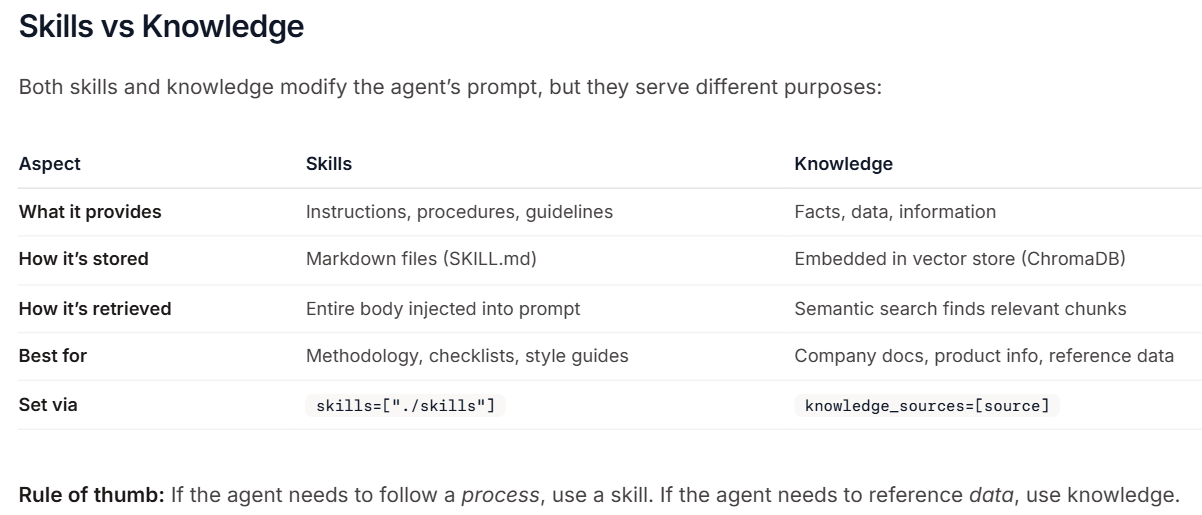